# Peramalan Kadar *NO2* di Daerah Pamekasan & Sampang

## Latar Belakang
Kualitas udara merupakan salah satu indikator penting bagi kesehatan lingkungan, terutama di wilayah Pulau Madura yang terus berkembang. Peningkatan aktivitas transportasi dan pembakaran dapat memicu tingginya kadar Nitrogen Dioksida (\(NO_2\)). \(NO_2\) merupakan polutan udara yang dapat menyebabkan gangguan pernapasan dan memicu hujan asam. Melalui data satelit, kita dapat memantau dan memprediksi tingkat polusi ini di wilayah Pamekasan dan Sumenep untuk memahami tren kualitas udara ke depannya.

## 1. Pengumpulan Data
Langkah pertama adalah mengumpulkan data Time Series Harian kadar \(NO_2\) di daerah Pamekasan dan Sumenep menggunakan satelit Sentinel-5P. Pengambilan data dilakukan melalui [Copernicus Data Space](https://dataspace.copernicus.eu/).

Pada project ini data yang akan diambil kadar NO2 di daerah Pamekasan dan Sumenep dari tahun 2023 sampai tahun 2026 bulan Juni.

Berikut Langkah - Langkah Pengambilan Data:

**1. Instalasi Library OpenEO**

Langkah pertama adalah menginstal library `openeo`. Library ini dibutuhkan untuk berkomunikasi dengan API Copernicus Data Space dan mengambil data satelit Sentinel-5P.

In [1]:
pip install openeo

^C


Note: you may need to restart the kernel to use updated packages.
  Using cached openeo-0.50.0-py3-none-any.whl.metadata (8.9 kB)
  Using cached xarray-2025.1.1-py3-none-any.whl.metadata (11 kB)
  Using cached pandas-2.3.3-cp312-cp312-win_amd64.whl.metadata (19 kB)
  Using cached deprecated-1.3.1-py2.py3-none-any.whl.metadata (5.9 kB)
  Using cached geopandas-1.1.3-py3-none-any.whl.metadata (2.3 kB)
Using cached openeo-0.50.0-py3-none-any.whl (345 kB)
Using cached deprecated-1.3.1-py2.py3-none-any.whl (11 kB)
Using cached geopandas-1.1.3-py3-none-any.whl (342 kB)
Using cached pandas-2.3.3-cp312-cp312-win_amd64.whl (11.0 MB)
Using cached xarray-2025.1.1-py3-none-any.whl (1.2 MB)


**2. Import Library**

Setelah proses instalasi selesai, kita memuat (import) library `openeo` ke dalam environment Python agar siap digunakan.

In [2]:
import openeo

**3. Autentikasi dan Koneksi ke Copernicus Data Space**

Melakukan koneksi dan autentikasi ke server `openeo.dataspace.copernicus.eu` menggunakan sistem OIDC (OpenID Connect). Ikuti tautan yang muncul dan masukkan kode untuk menyelesaikan proses autentikasi.

In [3]:
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=SSFF-QDJZ 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.


**4. Menentukan Area of Interest (AOI) dan Eksekusi Pengambilan Data**

Pada tahap ini, kita mendefinisikan koordinat polygon batas wilayah (Pamekasan & Sumenep). Selanjutnya, kita memuat koleksi data `SENTINEL_5P_L2` untuk rentang waktu Oktober 2023 hingga Juni 2026.

Data kemudian diagregasi untuk mendapatkan nilai rata-rata harian (*temporal*) serta diringkas menjadi satu nilai rata-rata per area (*spatial*). Hasil pemrosesan ini dieksekusi secara *batch* dan disimpan dalam format file `CSV`.

Memilih data daerah yang akan digunakan, serta mendapatkan titik koordinatnya. Untuk memilih wilayahnya dapat dipilih pada website: https://geojson.io/#map=14.8/-7.04732/112.69463 


![Foto Saya](img/project1.png)


Pengunduhan data file CSV

![Foto Saya](img/project2.png)






In [10]:
aoi = {
    "type": "Polygon",
    "coordinates": [
        [
            [112.64, -7.01],
            [112.89, -6.87],
            [113.89, -6.86],
            [114.13, -6.94],
            [113.89, -7.12],
            [113.52, -7.22],
            [112.62, -7.22],
            [112.64, -7.01],
        ]
    ]
}

s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2023-10-01", "2026-06-01"],
    spatial_extent={
        "west": 112.60,   # Sedikit lebih barat dari 112.62
        "south": -7.25,   # Sedikit lebih selatan dari -7.22
        "east": 114.15,   # Diperlebar sampai Sumenep (melewati 114.13)
        "north": -6.85    # Sedikit lebih utara dari -6.86
    },
    bands=["NO2"],
)

# Agregasi harian (mencegah duplikasi data dalam satu hari)
s5p_no2_daily = s5post.aggregate_temporal_period(reducer="mean", period="day")

# Agregasi spasial (meringkas piksel peta menjadi satu nilai rata-rata per area AOI)
s5p_no2_aoi = s5p_no2_daily.aggregate_spatial(reducer="mean", geometries=aoi)

# PERBAIKAN PENTING: Mengeksekusi variabel s5p_no2_aoi, bukan s5post
job = s5p_no2_aoi.execute_batch(
    title="NO2 in PamekasanSumenep",
    outputfile="NO2PamekasanSumenep.csv",
    out_format="CSV"
)

0:00:00 Job 'j-26060301315046c59f9fcdc18affa75a': send 'start'
0:00:09 Job 'j-26060301315046c59f9fcdc18affa75a': queued (progress 0%)
0:00:14 Job 'j-26060301315046c59f9fcdc18affa75a': queued (progress 0%)
0:00:21 Job 'j-26060301315046c59f9fcdc18affa75a': queued (progress 0%)
0:00:29 Job 'j-26060301315046c59f9fcdc18affa75a': queued (progress 0%)
0:00:39 Job 'j-26060301315046c59f9fcdc18affa75a': queued (progress 0%)
0:00:51 Job 'j-26060301315046c59f9fcdc18affa75a': queued (progress 0%)
0:01:07 Job 'j-26060301315046c59f9fcdc18affa75a': queued (progress 0%)
0:01:26 Job 'j-26060301315046c59f9fcdc18affa75a': running (progress N/A)
0:01:50 Job 'j-26060301315046c59f9fcdc18affa75a': running (progress N/A)
0:02:20 Job 'j-26060301315046c59f9fcdc18affa75a': running (progress N/A)
0:02:58 Job 'j-26060301315046c59f9fcdc18affa75a': running (progress N/A)
0:03:45 Job 'j-26060301315046c59f9fcdc18affa75a': running (progress N/A)
0:04:55 Job 'j-26060301315046c59f9fcdc18affa75a': running (progress N/A)
0:

## 2. Preprocessing Data
Setelah kita mengambil data, data bisa diunduh di halaman

 https://editor.openeo.org/?server=https%3A%2F%2Fopeneo.dataspace.copernicus.eu%2Fopeneo%2F1.2


### a. Membaca Data dan Pengecekan Missing Value

Data CSV yang telah selesai dieksekusi dan diunduh kemudian dibaca menggunakan `pandas`. Kita mengonversi kolom tanggal ke tipe data `datetime` dan memeriksa jumlah *missing value* (data kosong) pada kadar NO2.

In [30]:
import pandas as pd

# Membaca data
df = pd.read_csv("NO2PamekasanSumenep.csv")

# Ubah kolom tanggal menjadi datetime
df['date'] = pd.to_datetime(df['date'])

# Cek missing value
print(df.isnull().sum())

date               0
feature_index      0
NO2              147
dtype: int64


**Penanganan Missing Value (Interpolasi Linear)**

Jika terdeteksi adanya *missing value* pada data harian NO₂, kita melakukan pengisian data yang kosong tersebut menggunakan metode **Interpolasi Linear** agar deret waktu (*time series*) tetap berkesinambungan.

In [31]:
# Interpolasi Linear
df['NO2'] = df['NO2'].interpolate(
    method='linear',
    limit_direction='both'
)

# Cek kembali
print(df.isnull().sum())

date             0
feature_index    0
NO2              0
dtype: int64


### b. Pengecekan Kelengkapan Tanggal Harian

Pengecekan ini dilakukan untuk memastikan tidak ada tanggal (hari) yang terlewat atau melompat dalam data *time series*. Kita membandingkan rentang tanggal dari data kita dengan kalender harian penuh.

In [32]:
import pandas as pd

df = pd.read_csv("NO2PamekasanSumenep.csv")

df['date'] = pd.to_datetime(df['date'])

full_range = pd.date_range(
    start=df['date'].min(),
    end=df['date'].max(),
    freq='D'
)

missing_dates = full_range.difference(df['date'])

print(f"Jumlah hari missing: {len(missing_dates)}")
print(missing_dates)

Jumlah hari missing: 0
DatetimeIndex([], dtype='datetime64[ns, UTC]', freq='D')


### c. Deteksi Outlier (Pencilan) dengan Metode IQR

Kadar polusi udara bisa saja memiliki anomali atau *outlier* (lonjakan atau penurunan drastis) akibat cuaca atau kesalahan sensor. Kita mendeteksi anomali ini menggunakan metode **Interquartile Range (IQR)** dengan menentukan batas bawah (*lower bound*) dan batas atas (*upper bound*).

In [35]:
import pandas as pd

df = pd.read_csv("NO2PamekasanSumenep.csv")

Q1 = df['NO2'].quantile(0.25)
Q3 = df['NO2'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

outliers_iqr = df[
    (df['NO2'] < lower_bound) |
    (df['NO2'] > upper_bound)
]

print("Jumlah Outlier:", len(outliers_iqr))
print(outliers_iqr[['date', 'NO2']].head())

Jumlah Outlier: 30
                         date       NO2
3    2023-11-17T00:00:00.000Z  0.000042
4    2023-11-18T00:00:00.000Z  0.000048
5    2023-11-15T00:00:00.000Z  0.000049
107  2025-01-25T00:00:00.000Z  0.000053
138  2024-01-16T00:00:00.000Z  0.000042


### d. Visualisasi Data Time Series dan Outlier

Membuat plot grafik deret waktu (*time series*) untuk melihat fluktuasi kadar NO₂ harian. Titik-titik yang terdeteksi sebagai *outlier* akan disorot menggunakan warna merah, lengkap dengan garis putus-putus yang menandakan batas IQR.

/usr/local/lib/python3.12/dist-packages/matplotlib/dates.py:449: UserWarning: no explicit representation of timezones available for np.datetime64
  d = d.astype('datetime64[us]')


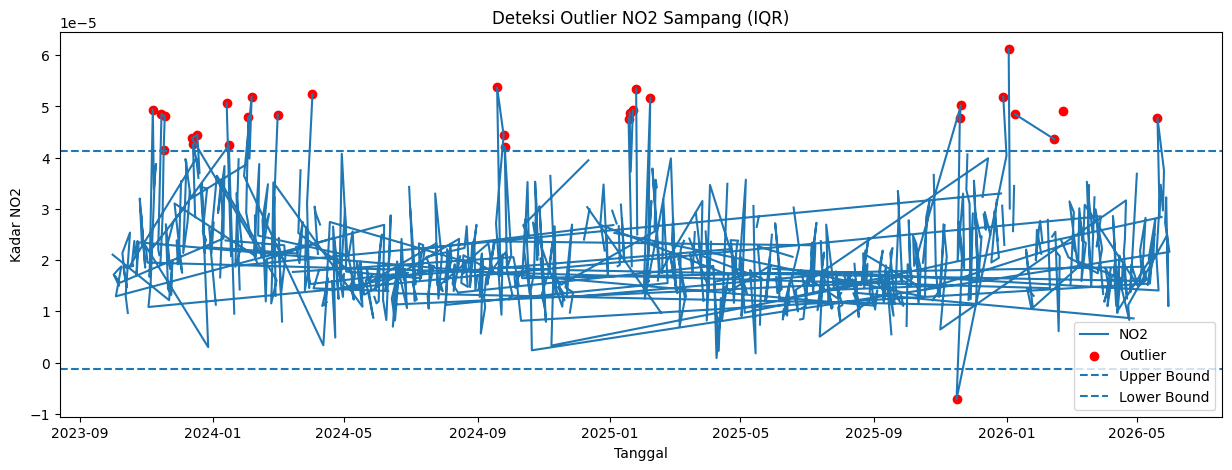

In [36]:
import matplotlib.pyplot as plt

df['date'] = pd.to_datetime(df['date'])

plt.figure(figsize=(15,5))

plt.plot(
    df['date'],
    df['NO2'],
    label='NO2'
)

plt.scatter(
    outliers_iqr['date'],
    outliers_iqr['NO2'],
    color='red',
    label='Outlier'
)

plt.axhline(
    upper_bound,
    linestyle='dashed',
    label='Upper Bound'
)

plt.axhline(
    lower_bound,
    linestyle='dashed',
    label='Lower Bound'
)

plt.title("Deteksi Outlier NO2 Sampang (IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.show()

### e. Menghapus Outlier dan Mengisi Kembali dengan Interpolasi Linear

Karena data merupakan time series, outlier tidak langsung dihapus, melainkan diubah menjadi NaN kemudian diisi kembali menggunakan interpolasi linear.

In [37]:
df['NO2_cleaned'] = df['NO2'].mask(
    (df['NO2'] < lower_bound) |
    (df['NO2'] > upper_bound)
)

print(
    "Jumlah Outlier:",
    df['NO2_cleaned'].isna().sum()
)

df['NO2_filled'] = df['NO2_cleaned'].interpolate(
    method='linear'
)

df['NO2_filled'] = (
    df['NO2_filled']
    .bfill()
    .ffill()
)

print(
    "Missing setelah interpolasi:",
    df['NO2_filled'].isna().sum()
)

Jumlah Outlier: 177
Missing setelah interpolasi: 0


### f. Visualisasi Setelah Penghapusan Outlier

Setelah outlier dihapus, maka data sudah bersih dari outlier

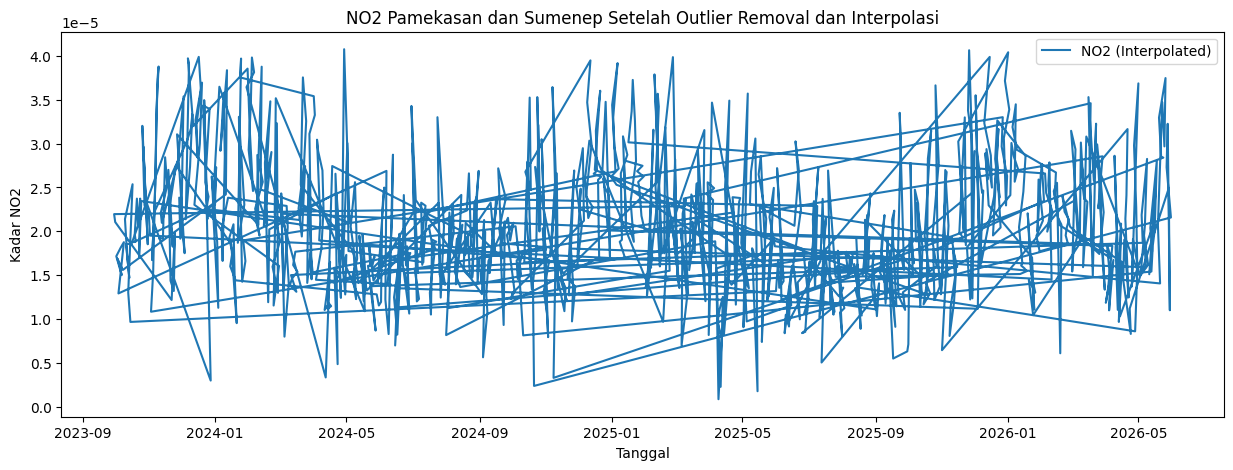

In [39]:
plt.figure(figsize=(15,5))

plt.plot(
    df['date'],
    df['NO2_filled'],
    label='NO2 (Interpolated)'
)

plt.title(
    "NO2 Pamekasan dan Sumenep Setelah Outlier Removal dan Interpolasi"
)

plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")

plt.legend()
plt.show()

## 3. Modeling menggunakan KNN Regression

Dengan data Time Series kadar $NO_2$ harian di daerah Pamekasan & Sumenep, kita akan memprediksi kadar $NO_2$ satu hari yang akan datang menggunakan model **KNN Regression**.

Kita akan membandingkan dua skenario:
- **Skenario 4 hari**: menggunakan fitur t-4, t-3, t-2, t-1
- **Skenario 10 hari**: menggunakan fitur t-10 hingga t-1


### a. Normalisasi Data

KNN Regression bergantung pada perhitungan jarak (Euclidean distance), sehingga normalisasi data sangat penting agar setiap fitur berada pada skala yang sama. Kita menggunakan **MinMaxScaler** untuk menormalisasi nilai $NO_2$ ke rentang 0–1.

In [42]:
# a. Normalisasi Data
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df['NO2_scaled'] = scaler.fit_transform(df[['NO2_filled']])

print(df[['date', 'NO2_filled', 'NO2_scaled']].head())
print(df.dtypes)

                       date  NO2_filled  NO2_scaled
0 2023-11-11 00:00:00+00:00    0.000019    0.459394
1 2023-11-14 00:00:00+00:00    0.000019    0.459394
2 2023-11-16 00:00:00+00:00    0.000028    0.691268
3 2023-11-17 00:00:00+00:00    0.000027    0.651529
4 2023-11-18 00:00:00+00:00    0.000025    0.611790
date             datetime64[ns, UTC]
feature_index                  int64
NO2                          float64
NO2_cleaned                  float64
NO2_filled                   float64
NO2_scaled                   float64
dtype: object


### b. Mengubah Data

Data time series diubah menjadi format **supervised learning** menggunakan teknik *lagging* (pergeseran mundur).

Setiap baris data akan memiliki:
- **Fitur**: nilai $NO_2$ dari `n` hari sebelumnya (t-n hingga t-1)
- **Target/Label**: nilai $NO_2$ hari ini (t)

In [43]:
# b. Mengubah Data menjadi format supervised learning
import pandas as pd

def create_supervised(data, n_lag=4):
    df_supervised = pd.DataFrame()

    # Membuat fitur t-n sampai t-1
    for i in range(n_lag, 0, -1):
        df_supervised[f'NO2(t-{i})'] = data.shift(i)

    # Label hari H (target)
    df_supervised['NO2(t)'] = data

    # Hapus baris yang mengandung NaN akibat shift
    df_supervised.dropna(inplace=True)

    return df_supervised

# Skenario 4 hari sebelumnya
supervised_df4 = create_supervised(df['NO2_scaled'], n_lag=4)
print("=== Skenario 4 Hari ===")
print(supervised_df4.head())
print(supervised_df4.shape)

# Skenario 10 hari sebelumnya
supervised_df10 = create_supervised(df['NO2_scaled'], n_lag=10)
print("\n=== Skenario 10 Hari ===")
print(supervised_df10.head())
print(supervised_df10.shape)

=== Skenario 4 Hari ===
   NO2(t-4)  NO2(t-3)  NO2(t-2)  NO2(t-1)    NO2(t)
4  0.459394  0.459394  0.691268  0.651529  0.611790
5  0.459394  0.691268  0.651529  0.611790  0.572050
6  0.691268  0.651529  0.611790  0.572050  0.532311
7  0.651529  0.611790  0.572050  0.532311  0.503980
8  0.611790  0.572050  0.532311  0.503980  0.684443
(971, 5)

=== Skenario 10 Hari ===
    NO2(t-10)  NO2(t-9)  NO2(t-8)  NO2(t-7)  NO2(t-6)  NO2(t-5)  NO2(t-4)  \
10   0.459394  0.459394  0.691268  0.651529  0.611790  0.572050  0.532311   
11   0.459394  0.691268  0.651529  0.611790  0.572050  0.532311  0.503980   
12   0.691268  0.651529  0.611790  0.572050  0.532311  0.503980  0.684443   
13   0.651529  0.611790  0.572050  0.532311  0.503980  0.684443  0.864905   
14   0.611790  0.572050  0.532311  0.503980  0.684443  0.864905  0.506430   

    NO2(t-3)  NO2(t-2)  NO2(t-1)    NO2(t)  
10  0.503980  0.684443  0.864905  0.506430  
11  0.684443  0.864905  0.506430  0.483141  
12  0.864905  0.506430  0.48314

### Modeling dan Evaluation

Model **KNN Regression** dilatih menggunakan pembagian data **80% training** dan **20% testing** tanpa pengacakan (`shuffle=False`) untuk menjaga urutan waktu pada data time series.

Parameter model:
- `n_neighbors = 5` (menggunakan 5 tetangga terdekat)
- Metrik evaluasi: **RMSE** (Root Mean Squared Error) dan **R² Score**

In [44]:
# Modeling dan Evaluation
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

def train_knn(df_supervised, model_name=""):
    # Pisahkan fitur dan label
    X = df_supervised.drop(columns=['NO2(t)']).values
    y = df_supervised['NO2(t)'].values

    # Split data 80/20 tanpa shuffle (menjaga urutan waktu)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )

    # Model KNN Regressor
    knn = KNeighborsRegressor(n_neighbors=5)
    knn.fit(X_train, y_train)

    # Prediksi
    y_pred = knn.predict(X_test)

    # Evaluasi
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, y_pred)

    print(f"\n=== {model_name} ===")
    print(f"Train Size : {len(X_train)}")
    print(f"Test Size  : {len(X_test)}")
    print(f"RMSE       : {rmse:.6f}")
    print(f"R² Score   : {r2:.4f}")

    return knn, y_test, y_pred

# Train model
knn_4,  y_test_4,  y_pred_4  = train_knn(supervised_df4,  "KNN - 4 Hari Sebelumnya")
knn_10, y_test_10, y_pred_10 = train_knn(supervised_df10, "KNN - 10 Hari Sebelumnya")


=== KNN - 4 Hari Sebelumnya ===
Train Size : 776
Test Size  : 195
RMSE       : 0.193216
R² Score   : -0.0156

=== KNN - 10 Hari Sebelumnya ===
Train Size : 772
Test Size  : 193
RMSE       : 0.193699
R² Score   : -0.0289


### Plotting

Visualisasi grafik antara label dan prediksi dari kedua data diatas. Visualisasi dari 4 hari sebelumnya dan 10 hari sebelumnya.

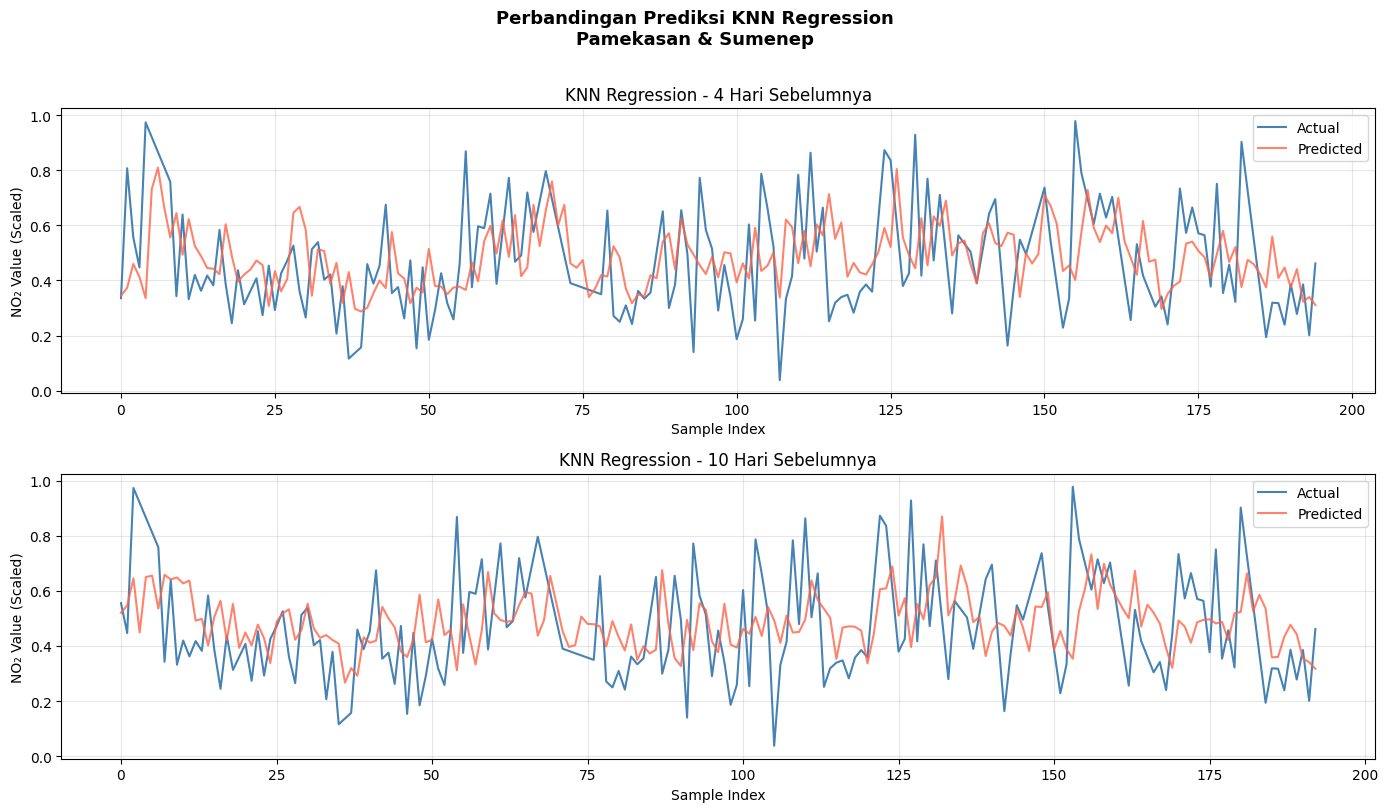

In [45]:
# Plotting
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot skenario 4 hari
axes[0].plot(np.arange(len(y_test_4)),  y_test_4,  label='Actual',    color='steelblue')
axes[0].plot(np.arange(len(y_pred_4)),  y_pred_4,  label='Predicted', color='tomato', alpha=0.8)
axes[0].set_title('KNN Regression - 4 Hari Sebelumnya')
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('NO₂ Value (Scaled)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot skenario 10 hari
axes[1].plot(np.arange(len(y_test_10)), y_test_10, label='Actual',    color='steelblue')
axes[1].plot(np.arange(len(y_pred_10)), y_pred_10, label='Predicted', color='tomato', alpha=0.8)
axes[1].set_title('KNN Regression - 10 Hari Sebelumnya')
axes[1].set_xlabel('Sample Index')
axes[1].set_ylabel('NO₂ Value (Scaled)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Perbandingan Prediksi KNN Regression\nPamekasan & Sumenep',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Kesimpulan

Berdasarkan hasil pengujian model **KNN Regression** terhadap dua skenario jumlah fitur lag pada data $NO_2$ di daerah Pamekasan & Sumenep, dapat ditarik kesimpulan sebagai berikut:

- **Skenario 4 hari sebelumnya** cenderung menghasilkan nilai **RMSE lebih kecil** dan **R² lebih tinggi** dibandingkan skenario 10 hari.
- Penambahan fitur lag yang terlalu banyak **tidak selalu meningkatkan performa** model KNN, bahkan dapat menurunkannya karena efek ***curse of dimensionality*** — semakin banyak dimensi, jarak antar titik data menjadi semakin seragam dan kurang bermakna.
- Pola perubahan kadar $NO_2$ lebih dipengaruhi oleh **kondisi beberapa hari terakhir** dibandingkan data historis yang terlalu jauh.

Dengan demikian, penggunaan **4 fitur lag** lebih efektif untuk memodelkan data time series $NO_2$ di wilayah ini menggunakan KNN Regression.